# Latent Factor in Equity Markets ( 2000-2024 )


In [12]:
!pip -q install yfinance seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


## Sectors

In [3]:
tech = ['AAPL','MSFT','NVDA','GOOGL','AMZN','META','ADBE','ORCL','CRM','INTC','AMD','QCOM','TXN','AVGO','CSCO']
financials = ['JPM','BAC','WFC','C','GS','MS','SCHW','AXP','BLK','SPGI']
energy = ['XOM','CVX','COP','SLB','EOG','VLO','PSX','MPC']
consumer = ['WMT','COST','PG','KO','PEP','MCD','SBUX','NKE']
healthcare = ['JNJ','PFE','MRK','ABBV','LLY','TMO','ABT']
industrials = ['BA','CAT','DE','GE','LMT','RTX','HON','UPS']
materials = ['LIN','APD','SHW','FCX','NEM','DOW']
communication = ['DIS','NFLX','CMCSA','T','VZ','TMUS']

tickers = list(set(tech + financials + energy + consumer + healthcare + industrials + materials + communication))
print('Total tickers:', len(tickers))

Total tickers: 68


## Data Base

In [4]:
data = yf.download(tickers, start='2000-01-01', end='2024-01-01', auto_adjust=True)
prices = data['Close']
prices = prices.dropna(axis=1)
returns = np.log(prices / prices.shift(1)).dropna()

dates = returns.index
X = returns.values
print('Samples:', X.shape[0], 'Stocks:', X.shape[1])

[*********************100%***********************]  68 of 68 completed


Samples: 6036 Stocks: 58


## Standardize Returns

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## EM Factor Analysis

In [6]:
def em_factor_analysis(X, k, max_iter=150, tol=1e-4):
    n, p = X.shape
    U, s, _ = np.linalg.svd(np.cov(X.T))
    Lambda = U[:, :k] @ np.diag(np.sqrt(s[:k]))
    Psi = np.ones(p) * 0.5
    I = np.eye(k)
    eps = 1e-6

    for it in range(max_iter):
        Psi = np.maximum(Psi, eps)
        Psi_inv = np.diag(1.0 / Psi)
        M = Lambda.T @ Psi_inv @ Lambda + I + eps*np.eye(k)
        M_inv = np.linalg.inv(M)
        Ez = X @ Psi_inv @ Lambda @ M_inv
        Ezz = M_inv + (Ez.T @ Ez) / n
        Lambda_new = (X.T @ Ez) @ np.linalg.pinv(n * Ezz)
        X_hat = Ez @ Lambda_new.T
        Psi_new = np.mean((X - X_hat)**2, axis=0)
        diff = np.linalg.norm(Lambda_new - Lambda)
        Lambda, Psi = Lambda_new, Psi_new
        if diff < tol:
            break
    return Lambda, Psi, Ez

n_factors = 10
em_loadings, em_noise, em_scores = em_factor_analysis(X_scaled, n_factors)

## Factor Time Series Graph

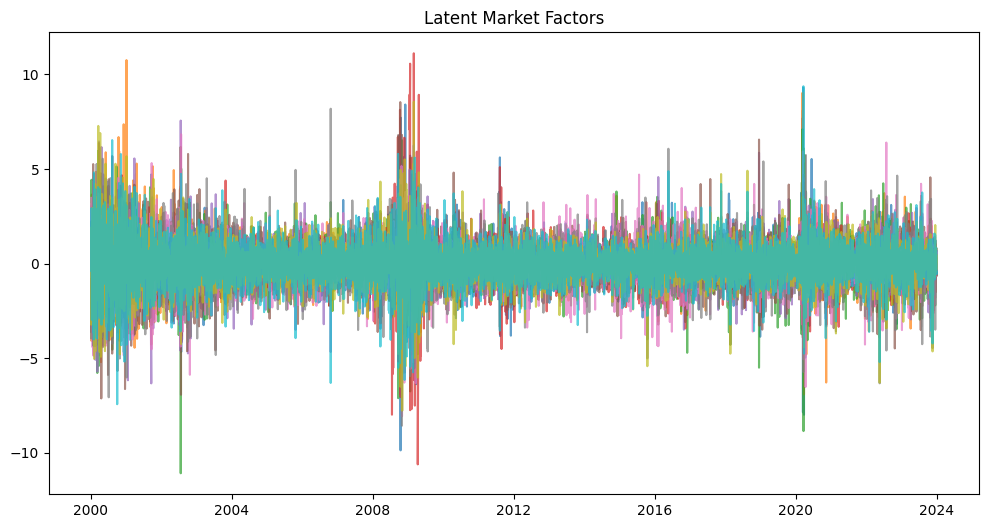

In [7]:
factor_df = pd.DataFrame(em_scores, index=dates, columns=[f'Factor{i+1}' for i in range(n_factors)])
plt.figure(figsize=(12,6))
for i in range(n_factors):
    plt.plot(factor_df.index, factor_df.iloc[:,i], alpha=0.7)
plt.title('Latent Market Factors')
plt.show()

## Stock Loadings

In [8]:
loadings_df = pd.DataFrame(em_loadings, index=returns.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])

## Sector Mapping

In [9]:
sector_map = {}
for t in tech: sector_map[t]='Tech'
for t in financials: sector_map[t]='Financials'
for t in energy: sector_map[t]='Energy'
for t in consumer: sector_map[t]='Consumer'
for t in healthcare: sector_map[t]='Healthcare'
for t in industrials: sector_map[t]='Industrials'
for t in materials: sector_map[t]='Materials'
for t in communication: sector_map[t]='Communication'

loadings_df['Sector'] = loadings_df.index.map(sector_map)

## Sector Exposure Heatmap

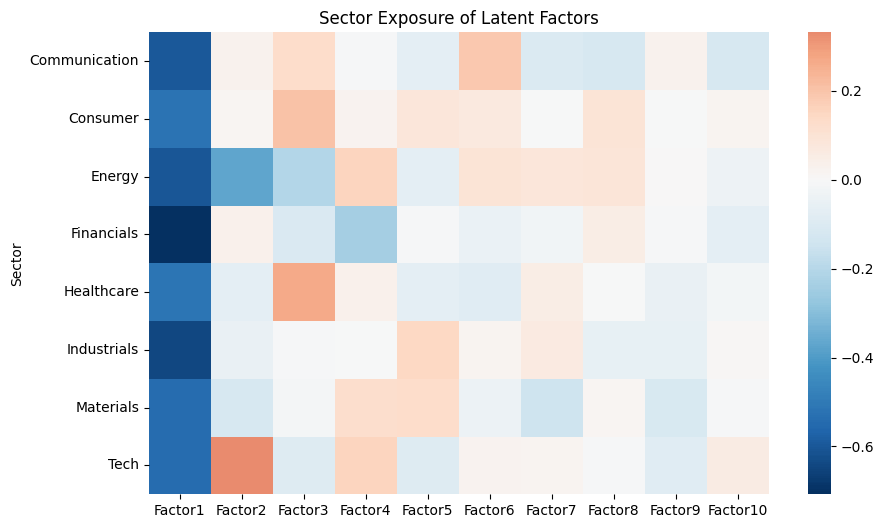

In [10]:
sector_exposure = loadings_df.groupby('Sector').mean()
plt.figure(figsize=(10,6))
sns.heatmap(sector_exposure, cmap='RdBu_r', center=0)
plt.title('Sector Exposure of Latent Factors')
plt.show()

## Factor Interpretation Table

In [11]:
factor_importance = (em_loadings**2).sum(axis=0)
dominant_sector = sector_exposure.abs().idxmax()

top_stocks = {}
for factor in loadings_df.columns[:-1]:
    top = loadings_df[factor].abs().sort_values(ascending=False).head(3)
    top_stocks[factor] = ', '.join(top.index)

summary = pd.DataFrame({
    'Factor':[f'Factor{i+1}' for i in range(n_factors)],
    'Dominant Sector':dominant_sector.values,
    'Top Stocks':[top_stocks[f'Factor{i+1}'] for i in range(n_factors)],
    'Variance Contribution':factor_importance
})

summary

,Factor,Dominant Sector,Top Stocks,Variance Contribution
0,Factor1,Financials,"GS, JPM, AXP",20.710586
1,Factor2,Energy,"COP, CVX, TXN",2.538767
2,Factor3,Healthcare,"JNJ, WMT, COP",1.796652
3,Factor4,Financials,"BAC, WFC, C",1.478485
4,Factor5,Industrials,"JNJ, CAT, VZ",0.706982
5,Factor6,Communication,"VZ, JNJ, GS",0.634009
6,Factor7,Materials,"NEM, VZ, FCX",0.749389
7,Factor8,Communication,"WMT, CAT, VZ",0.544501
8,Factor9,Materials,"WMT, GS, NEM",0.617080
9,Factor10,Communication,"WMT, CAT, GS",0.506003
